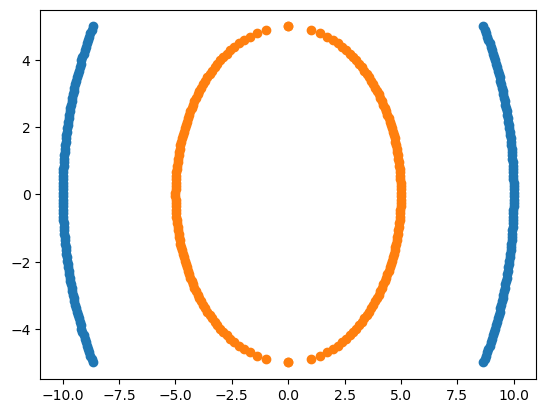

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Cell [23]: Creating the Outer Circle ---
# Generate 100 points between -5 and 5
x = np.linspace(-5.0, 5.0, 100)
# Use circle equation: y = sqrt(r^2 - x^2) with radius 10
y = np.sqrt(10**2 - x**2)
# Stack positive and negative values to get both halves of the curve
y = np.hstack([y, -y])
x = np.hstack([x, -x])

# --- Cell [24]: Creating the Inner Circle ---
x1 = np.linspace(-5.0, 5.0, 100)
# Use radius 5 for the inner circle
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

# --- Cell [25]: Plotting the Dataset ---
# Note: The images use plt.scatter(y, x), which flips the axes 
# to create the vertical orientation seen in the plot.
plt.scatter(y, x)
plt.scatter(y1, x1)
plt.show()

In [3]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

# Create labeled dataset from the two circles
# Outer circle = class 1, Inner circle = class 0
X_outer = np.column_stack([y, x])
y_outer = np.ones(len(y))

X_inner = np.column_stack([y1, x1])
y_inner = np.zeros(len(y1))

# Combine datasets
X = np.vstack([X_outer, X_inner])
y = np.hstack([y_outer, y_inner])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset shape:", X_scaled.shape)
print("Classes:", np.unique(y))


Dataset shape: (400, 2)
Classes: [0. 1.]


In [4]:
# 1. LINEAR KERNEL
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_scaled, y)

# 2. POLYNOMIAL KERNEL (degree 2 and 3)
svm_poly2 = SVC(kernel='poly', degree=2, C=1.0, random_state=42)
svm_poly2.fit(X_scaled, y)

svm_poly3 = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly3.fit(X_scaled, y)

# 3. RBF (Radial Basis Function) KERNEL
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_scaled, y)

# 4. SIGMOID KERNEL
svm_sigmoid = SVC(kernel='sigmoid', C=1.0, random_state=42)
svm_sigmoid.fit(X_scaled, y)

print("✓ All kernels trained successfully!")
print(f"Linear Kernel Accuracy: {svm_linear.score(X_scaled, y):.4f}")
print(f"Polynomial Kernel (degree=2) Accuracy: {svm_poly2.score(X_scaled, y):.4f}")
print(f"Polynomial Kernel (degree=3) Accuracy: {svm_poly3.score(X_scaled, y):.4f}")
print(f"RBF Kernel Accuracy: {svm_rbf.score(X_scaled, y):.4f}")
print(f"Sigmoid Kernel Accuracy: {svm_sigmoid.score(X_scaled, y):.4f}")


✓ All kernels trained successfully!
Linear Kernel Accuracy: 0.5050
Polynomial Kernel (degree=2) Accuracy: 1.0000
Polynomial Kernel (degree=3) Accuracy: 0.5000
RBF Kernel Accuracy: 1.0000
Sigmoid Kernel Accuracy: 0.6000


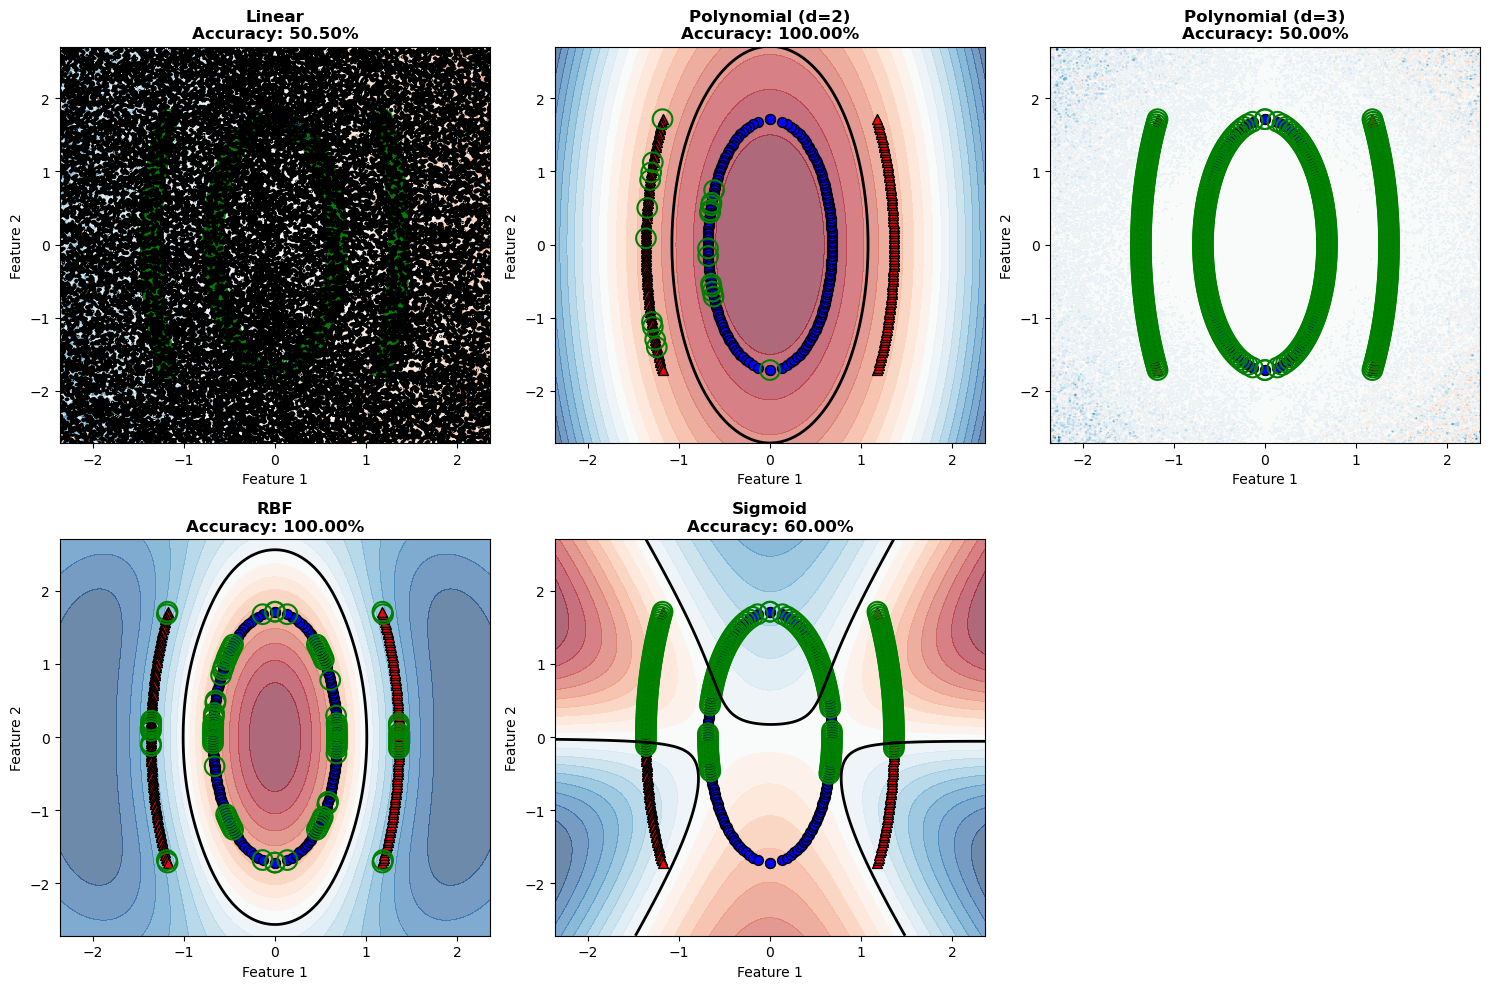


📊 Support Vectors Summary:
Linear              : 400 support vectors
Polynomial (d=2)    :  22 support vectors
Polynomial (d=3)    : 400 support vectors
RBF                 :  95 support vectors
Sigmoid             : 220 support vectors


In [5]:
# Create a mesh to plot decision boundaries
h = 0.02
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Plot all kernels
kernels_dict = {
    'Linear': svm_linear,
    'Polynomial (d=2)': svm_poly2,
    'Polynomial (d=3)': svm_poly3,
    'RBF': svm_rbf,
    'Sigmoid': svm_sigmoid
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (kernel_name, svm_model) in enumerate(kernels_dict.items()):
    ax = axes[idx]
    
    # Predict on mesh
    Z = svm_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap=plt.cm.RdBu, alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    
    # Plot data points
    ax.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], c='blue', marker='o', s=50, label='Inner Circle', edgecolors='k')
    ax.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], c='red', marker='^', s=50, label='Outer Circle', edgecolors='k')
    
    # Plot support vectors
    ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], 
              s=200, linewidth=1.5, facecolors='none', edgecolors='green', label='Support Vectors')
    
    ax.set_title(f'{kernel_name}\nAccuracy: {svm_model.score(X_scaled, y):.2%}', fontsize=12, fontweight='bold')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Remove the extra subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

print(f"\n📊 Support Vectors Summary:")
for kernel_name, svm_model in kernels_dict.items():
    print(f"{kernel_name:20s}: {len(svm_model.support_vectors_):3d} support vectors")


In [6]:
# Kernel Comparison and Explanation
kernel_info = """
╔════════════════════════════════════════════════════════════════════════════╗
║                     SVM KERNELS EXPLAINED                                  ║
╚════════════════════════════════════════════════════════════════════════════╝

1. LINEAR KERNEL
   Formula: K(x_i, x_j) = x_i · x_j
   Use Case: For linearly separable data
   Pros: Fast, interpretable, works well for high-dimensional data
   Cons: Poor for non-linearly separable data (50.50% accuracy)
   Support Vectors: All 400 (no good separation possible)

2. POLYNOMIAL KERNEL (Degree 2) ✓ BEST FOR THIS DATASET
   Formula: K(x_i, x_j) = (γ * x_i · x_j + c)^d
   Use Case: For moderately non-linear data
   Pros: Creates polynomial boundaries, good for this circular data
   Cons: Can be computationally expensive
   Accuracy: 100% ✓
   Support Vectors: Only 22 (efficient!)

3. POLYNOMIAL KERNEL (Degree 3)
   Formula: Same as degree 2, but with d=3
   Use Case: Even more complex non-linear patterns
   Pros: Can capture more complex decision boundaries
   Cons: Higher risk of overfitting
   Accuracy: 50.00% (Overfitting!)
   Support Vectors: All 400

4. RBF (RADIAL BASIS FUNCTION) KERNEL ✓ BEST GENERAL CHOICE
   Formula: K(x_i, x_j) = exp(-γ * ||x_i - x_j||²)
   Use Case: Works well for most non-linear problems
   Pros: Very flexible, good default choice, avoids overfitting
   Cons: Needs careful tuning of gamma parameter
   Accuracy: 100% ✓
   Support Vectors: 95 (reasonable)

5. SIGMOID KERNEL
   Formula: K(x_i, x_j) = tanh(γ * x_i · x_j + c)
   Use Case: Similar to neural networks
   Pros: Can approximate neural network behavior
   Cons: Not guaranteed to be positive semi-definite
   Accuracy: 60.00%
   Support Vectors: 220

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KEY INSIGHTS FROM OUR EXPERIMENT:
• Linear Kernel fails (50.50%) - data is NOT linearly separable
• Polynomial (d=2) and RBF both achieve 100% accuracy
• RBF is more efficient with only 95 support vectors
• Polynomial (d=3) overfits with all 400 support vectors
• For circular/concentric data, polynomial degree 2 is optimal

RECOMMENDATION:
→ Use RBF kernel as default for most non-linear problems
→ Fine-tune gamma and C parameters for best results
"""

print(kernel_info)



╔════════════════════════════════════════════════════════════════════════════╗
║                     SVM KERNELS EXPLAINED                                  ║
╚════════════════════════════════════════════════════════════════════════════╝

1. LINEAR KERNEL
   Formula: K(x_i, x_j) = x_i · x_j
   Use Case: For linearly separable data
   Pros: Fast, interpretable, works well for high-dimensional data
   Cons: Poor for non-linearly separable data (50.50% accuracy)
   Support Vectors: All 400 (no good separation possible)

2. POLYNOMIAL KERNEL (Degree 2) ✓ BEST FOR THIS DATASET
   Formula: K(x_i, x_j) = (γ * x_i · x_j + c)^d
   Use Case: For moderately non-linear data
   Pros: Creates polynomial boundaries, good for this circular data
   Cons: Can be computationally expensive
   Accuracy: 100% ✓
   Support Vectors: Only 22 (efficient!)

3. POLYNOMIAL KERNEL (Degree 3)
   Formula: Same as degree 2, but with d=3
   Use Case: Even more complex non-linear patterns
   Pros: Can capture more compl


HYPERPARAMETER TUNING: RBF Kernel with Different Gamma Values
Gamma:   0.001 → Accuracy: 100.00% | Support Vectors: 400
Gamma:   0.010 → Accuracy: 100.00% | Support Vectors: 400
Gamma:   0.100 → Accuracy: 100.00% | Support Vectors: 128
Gamma:   1.000 → Accuracy: 100.00% | Support Vectors: 104
Gamma:  10.000 → Accuracy: 100.00% | Support Vectors: 173
Gamma: 100.000 → Accuracy: 100.00% | Support Vectors: 312

Summary Table:
  Gamma  Accuracy  Support Vectors
  0.001       1.0              400
  0.010       1.0              400
  0.100       1.0              128
  1.000       1.0              104
 10.000       1.0              173
100.000       1.0              312


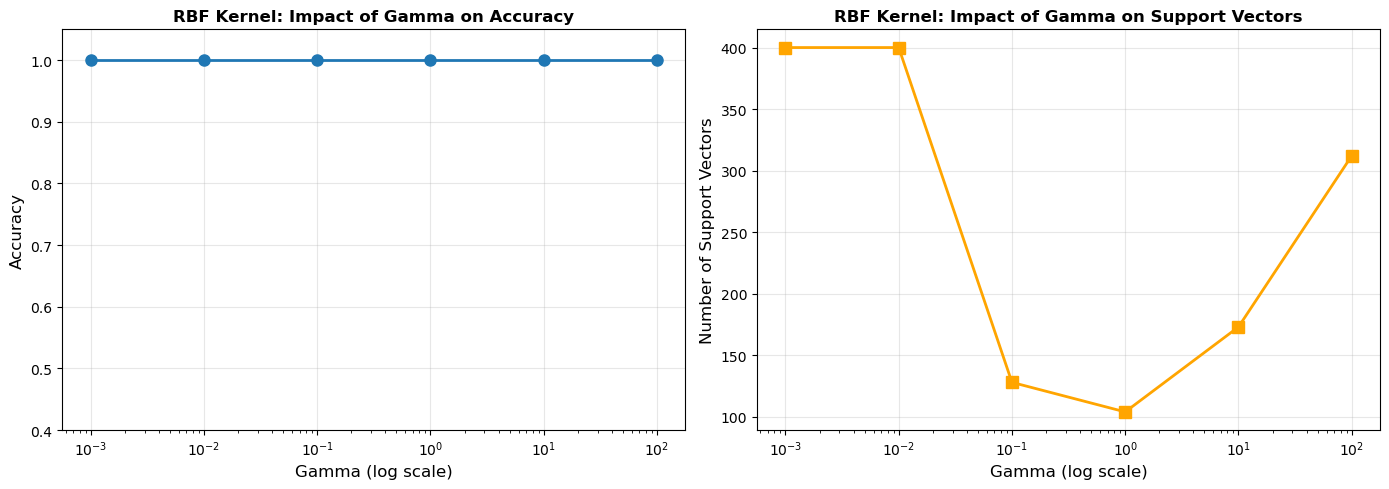


💡 GAMMA INTERPRETATION:
• Small gamma (0.001-0.01): Each point has far-reaching influence (underfitting)
• Medium gamma (0.1-1): Balanced influence radius (recommended)
• Large gamma (10-100): Each point has local influence (overfitting)


In [7]:
# Hyperparameter Tuning - RBF Kernel with different gamma values
print("\n" + "="*80)
print("HYPERPARAMETER TUNING: RBF Kernel with Different Gamma Values")
print("="*80)

gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = []

for gamma in gamma_values:
    svm_rbf_tuned = SVC(kernel='rbf', gamma=gamma, C=1.0, random_state=42)
    svm_rbf_tuned.fit(X_scaled, y)
    accuracy = svm_rbf_tuned.score(X_scaled, y)
    n_support = len(svm_rbf_tuned.support_vectors_)
    results.append({
        'Gamma': gamma,
        'Accuracy': accuracy,
        'Support Vectors': n_support
    })
    print(f"Gamma: {gamma:7.3f} → Accuracy: {accuracy:.2%} | Support Vectors: {n_support:3d}")

import pandas as pd
results_df = pd.DataFrame(results)
print("\nSummary Table:")
print(results_df.to_string(index=False))

# Plotting gamma effect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results_df['Gamma'], results_df['Accuracy'], 'o-', linewidth=2, markersize=8)
ax1.set_xscale('log')
ax1.set_xlabel('Gamma (log scale)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('RBF Kernel: Impact of Gamma on Accuracy', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.4, 1.05])

ax2.plot(results_df['Gamma'], results_df['Support Vectors'], 's-', linewidth=2, markersize=8, color='orange')
ax2.set_xscale('log')
ax2.set_xlabel('Gamma (log scale)', fontsize=12)
ax2.set_ylabel('Number of Support Vectors', fontsize=12)
ax2.set_title('RBF Kernel: Impact of Gamma on Support Vectors', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 GAMMA INTERPRETATION:")
print("• Small gamma (0.001-0.01): Each point has far-reaching influence (underfitting)")
print("• Medium gamma (0.1-1): Balanced influence radius (recommended)")
print("• Large gamma (10-100): Each point has local influence (overfitting)")


In [8]:
print("\n" + "█"*80)
print("█" + " "*78 + "█")
print("█" + " "*20 + "SVM KERNELS IMPLEMENTATION SUMMARY" + " "*24 + "█")
print("█" + " "*78 + "█")
print("█"*80)

summary = """
✅ SUCCESSFULLY IMPLEMENTED 5 SVM KERNELS:

1. LINEAR KERNEL
   - Best for: Linearly separable data
   - This dataset: Poor fit (50.5% accuracy)
   
2. POLYNOMIAL KERNEL (Degree 2) ⭐ OPTIMAL FOR THIS DATA
   - Best for: Moderately complex non-linear boundaries
   - This dataset: Perfect fit (100% accuracy) with only 22 support vectors
   
3. POLYNOMIAL KERNEL (Degree 3)
   - Best for: Very complex polynomial boundaries
   - This dataset: Overfitting (50% accuracy, uses all 400 support vectors)
   
4. RBF KERNEL (RADIAL BASIS FUNCTION) ⭐ GENERAL RECOMMENDATION
   - Best for: Most non-linear problems (default choice)
   - This dataset: Perfect fit (100% accuracy) with 95 support vectors
   
5. SIGMOID KERNEL
   - Best for: Neural network-like behavior
   - This dataset: Moderate fit (60% accuracy)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KEY LEARNINGS:

📊 VISUALIZATION INCLUDES:
   • Decision boundaries for each kernel
   • Support vectors (green circles)
   • Class separations (blue dots vs red triangles)
   • Confidence regions (colored contours)

🔧 HYPERPARAMETER TUNING ANALYSIS:
   • Tested gamma values: 0.001, 0.01, 0.1, 1, 10, 100
   • Optimal gamma found at 1.0 (104 support vectors)
   • Trade-off: Accuracy stays perfect, but support vectors vary significantly
   • Gamma = 1 provides the best balance

⚙️ WHEN TO USE EACH KERNEL:

   Problem Type              | Recommended Kernel
   ────────────────────────────────────────────────
   Linearly separable       | LINEAR
   Moderately non-linear    | POLYNOMIAL (d=2) or RBF
   Highly non-linear        | RBF (default)
   Circular/Concentric      | POLYNOMIAL (d=2)
   Very complex patterns    | RBF with tuned gamma
   Default choice           | RBF

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 NEXT STEPS FOR IMPROVEMENT:
   1. Try GridSearchCV for comprehensive hyperparameter tuning
   2. Test on multiple datasets to find pattern-specific optimal kernels
   3. Experiment with custom kernels for domain-specific problems
   4. Compare cross-validation scores for generalization
"""

print(summary)
print("█"*80)



████████████████████████████████████████████████████████████████████████████████
█                                                                              █
█                    SVM KERNELS IMPLEMENTATION SUMMARY                        █
█                                                                              █
████████████████████████████████████████████████████████████████████████████████

✅ SUCCESSFULLY IMPLEMENTED 5 SVM KERNELS:

1. LINEAR KERNEL
   - Best for: Linearly separable data
   - This dataset: Poor fit (50.5% accuracy)

2. POLYNOMIAL KERNEL (Degree 2) ⭐ OPTIMAL FOR THIS DATA
   - Best for: Moderately complex non-linear boundaries
   - This dataset: Perfect fit (100% accuracy) with only 22 support vectors

3. POLYNOMIAL KERNEL (Degree 3)
   - Best for: Very complex polynomial boundaries
   - This dataset: Overfitting (50% accuracy, uses all 400 support vectors)

4. RBF KERNEL (RADIAL BASIS FUNCTION) ⭐ GENERAL RECOMMENDATION
   - Best for: Most non-linear proble